In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('dark')

In [3]:
df=pd.read_csv("..\\data\\yield_df.csv")
df.head(10)

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37
5,5,Albania,Wheat,1990,30197,1485.0,121.0,16.37
6,6,Albania,Maize,1991,29068,1485.0,121.0,15.36
7,7,Albania,Potatoes,1991,77818,1485.0,121.0,15.36
8,8,Albania,"Rice, paddy",1991,28538,1485.0,121.0,15.36
9,9,Albania,Sorghum,1991,6667,1485.0,121.0,15.36


Exploration

In [4]:
df.drop(df.columns[0], axis=1,inplace=True)
df.sample(10)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
28057,Zambia,Wheat,2013,65435,1020.0,1670.00,20.14
24160,Saudi Arabia,Potatoes,1991,175355,59.0,994.00,25.43
26631,Turkey,Potatoes,1994,229189,593.0,24219.00,11.70
6851,Colombia,Potatoes,2009,183793,3240.0,51435.13,27.68
8096,Egypt,Potatoes,1991,202345,51.0,8255.00,21.65
8181,Egypt,"Rice, paddy",1997,84152,51.0,4607.00,20.52
13214,India,"Rice, paddy",2006,31759,1083.0,37423.00,26.37
26508,Tunisia,Sorghum,2008,4691,207.0,462.80,19.76
13520,India,Maize,2008,24140,1083.0,14485.33,25.35
1342,Australia,Sweet potatoes,2002,347368,534.0,26651.00,16.63


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,28242.0,2001.544296,7.051905,1990.00,1995.0000,2001.00,2008.00,2013.00
hg/ha_yield,28242.0,77053.332094,84956.612897,50.00,19919.2500,38295.00,104676.75,501412.00
average_rain_fall_mm_per_year,28242.0,1149.055980,709.812150,51.00,593.0000,1083.00,1668.00,3240.00
pesticides_tonnes,28242.0,37076.909344,59958.784665,0.04,1702.0000,17529.44,48687.88,367778.00
avg_temp,28242.0,20.542627,6.312051,1.30,16.7025,21.51,26.00,30.65


In [7]:
df.isnull().sum().sort_values(ascending=False)

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [8]:
df.duplicated()[df.duplicated()==True]

2083     True
2085     True
2087     True
2089     True
2091     True
         ... 
27690    True
27695    True
27700    True
27705    True
27710    True
Length: 2310, dtype: bool

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum().sort_values(ascending=False)

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [11]:
df.nunique()

Area                               101
Item                                10
Year                                23
hg/ha_yield                      11514
average_rain_fall_mm_per_year      100
pesticides_tonnes                 1673
avg_temp                          1831
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25932 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           25932 non-null  object 
 1   Item                           25932 non-null  object 
 2   Year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.6+ MB


In [13]:
df.select_dtypes(include=np.number).columns

Index(['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [14]:
df.to_csv("..\\data\\yield_df_cleaned.csv", index=False)

Climate Impact Analysis

In [15]:
sns.set_theme(style="whitegrid", palette="GnBu")

Distribution of Numerical columns

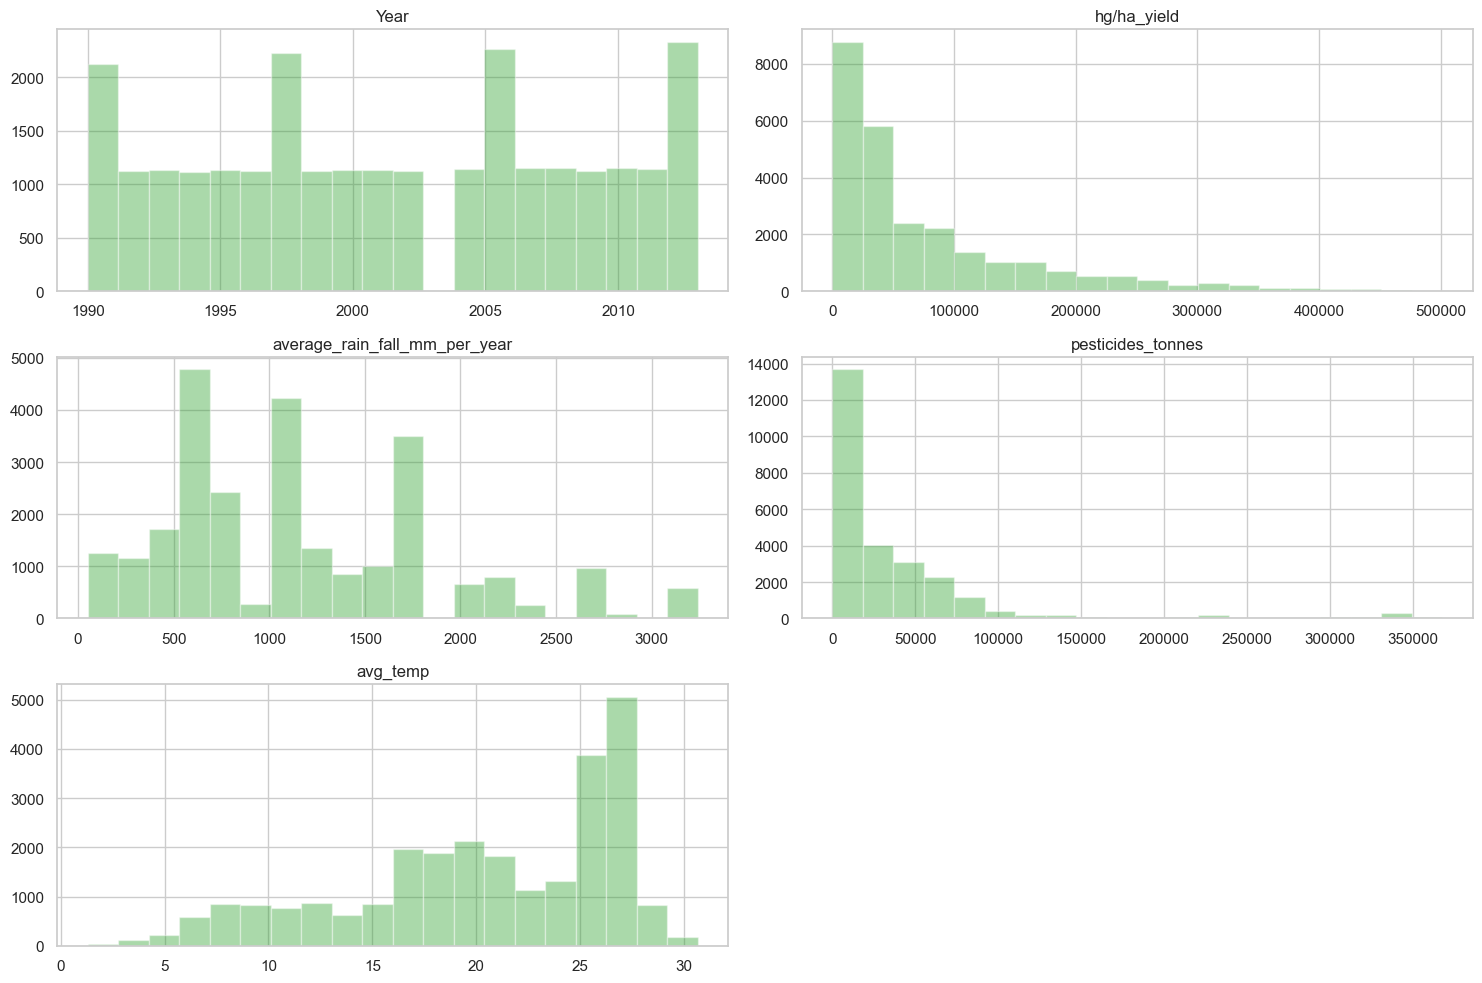

In [16]:
df.hist(figsize=(15,10),bins=20,color='tab:green', alpha=0.4)
plt.tight_layout()
plt.show()

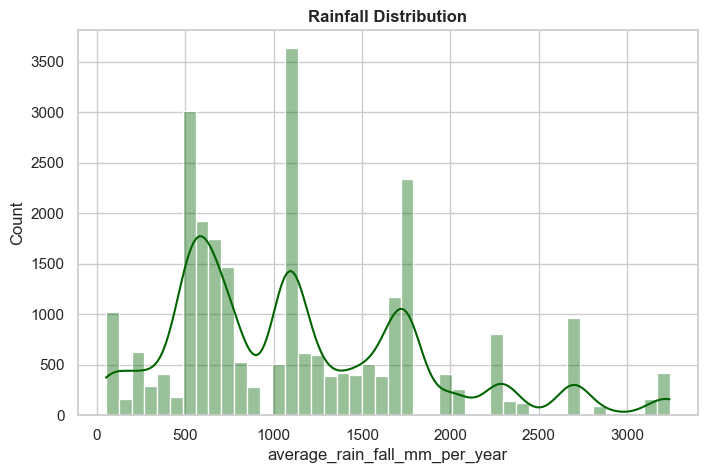

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['average_rain_fall_mm_per_year'],kde=True,color='darkgreen', alpha=0.4)
plt.title('Rainfall Distribution', fontweight='bold')
plt.show()


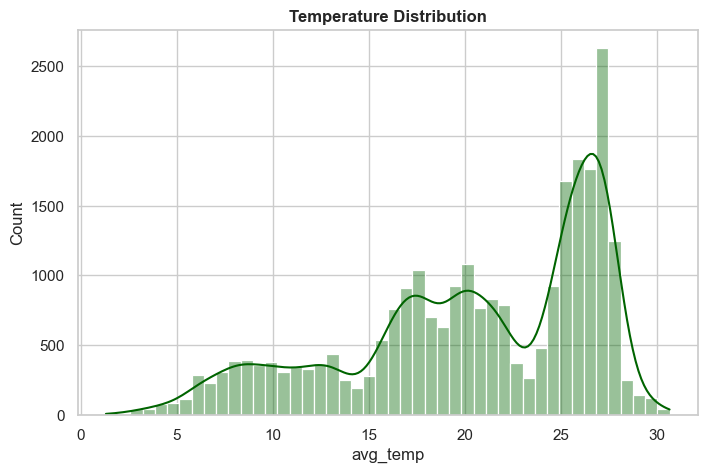

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_temp'],kde=True,color='darkgreen', alpha=0.4)
plt.title('Temperature Distribution', fontweight='bold')
plt.show()


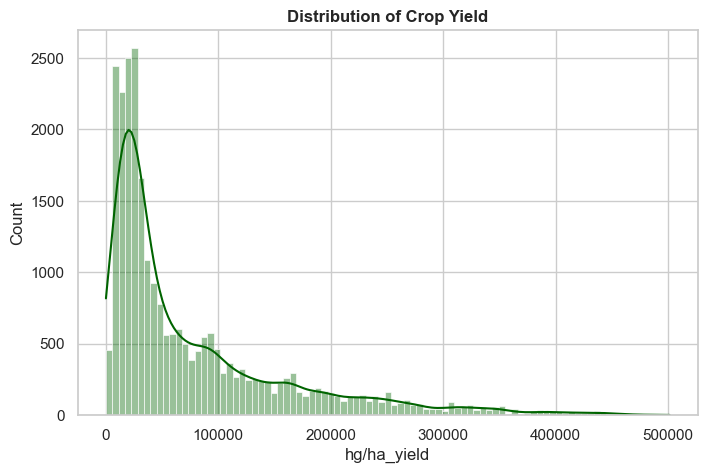

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['hg/ha_yield'],kde=True,color='darkgreen', alpha=0.4)
plt.title('Distribution of Crop Yield', fontweight='bold')
plt.show()

Correlation between numerical coulumns

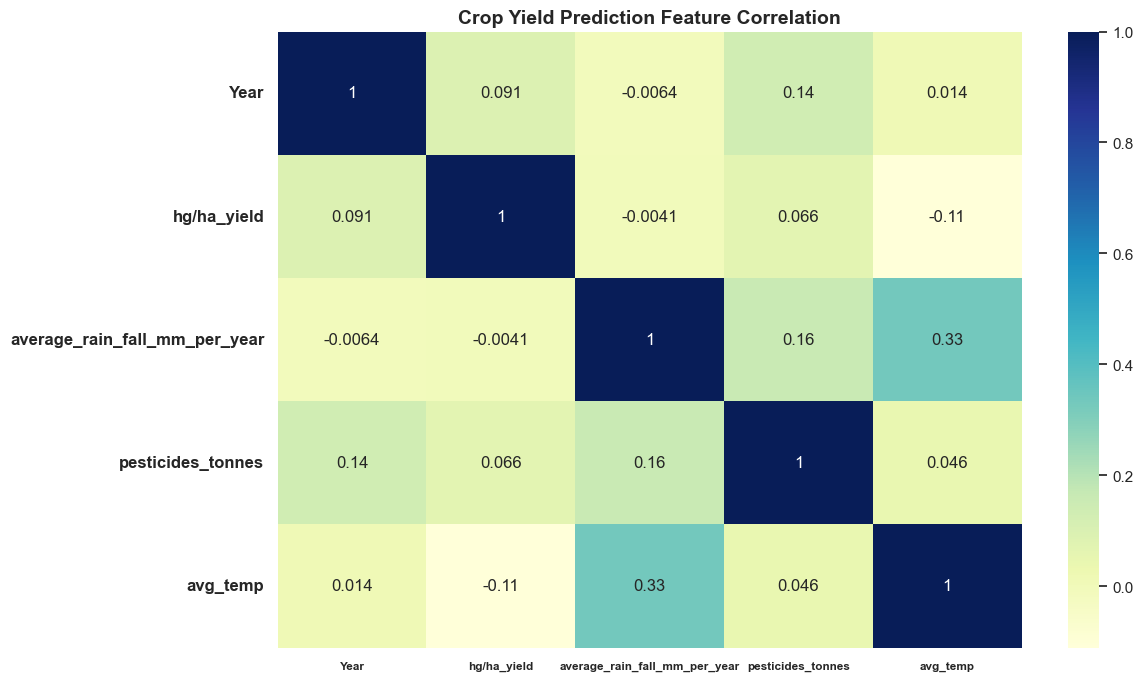

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='YlGnBu')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.xticks(fontsize=8.5,fontweight='bold')
plt.yticks(fontsize=12,fontweight='bold')
plt.title('Crop Yield Prediction Feature Correlation',fontweight='bold',fontsize=14)
plt.show()

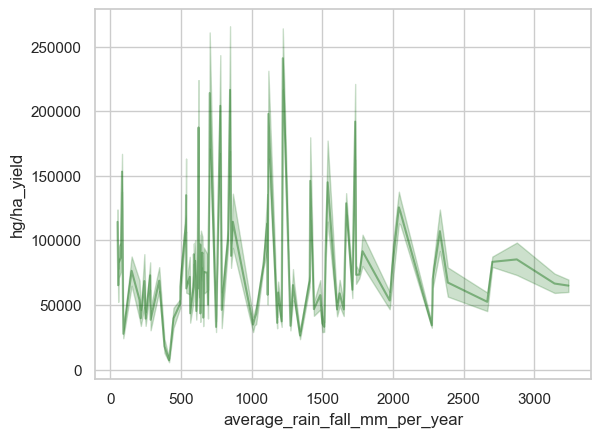

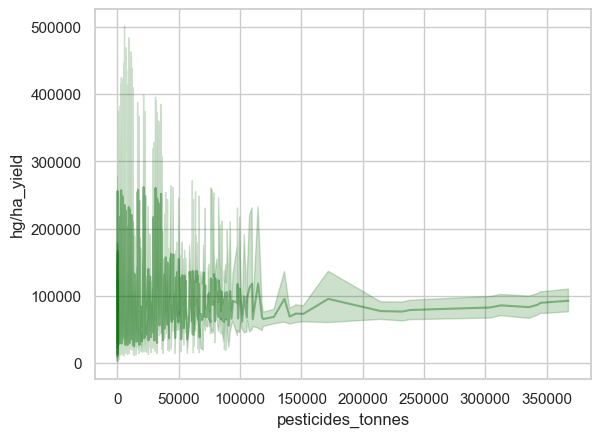

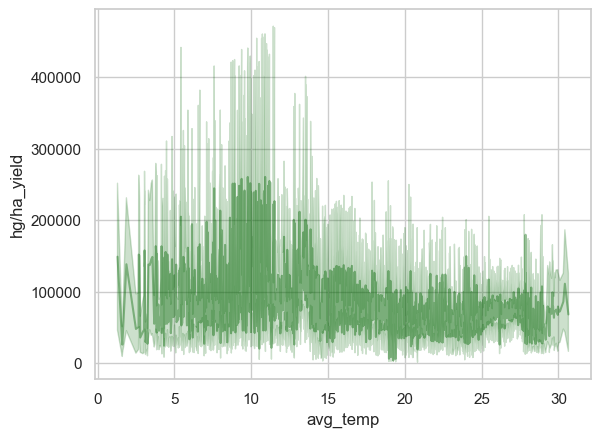

In [ ]:
features = ['average_rain_fall_mm_per_year','pesticides_tonnes', 'avg_temp']

for col in features:
    sns.lineplot(data=df,x=col,y='hg/ha_yield',color='darkgreen', alpha=0.4)
    plt.grid(True)
    plt.show()

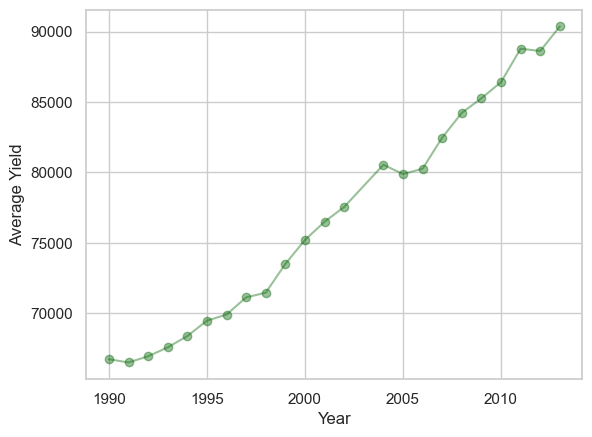

In [ ]:
yield_year = df.groupby('Year')['hg/ha_yield'].mean()

yield_year.plot(marker='o',color='darkgreen', alpha=0.4)
plt.ylabel('Average Yield')
plt.show()

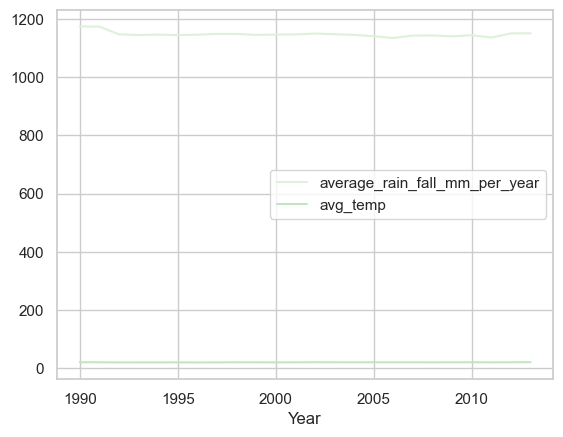

In [ ]:
for col in ['average_rain_fall_mm_per_year','avg_temp']:
    df.groupby('Year')[col].mean().plot(label=col)

plt.legend()
plt.show()

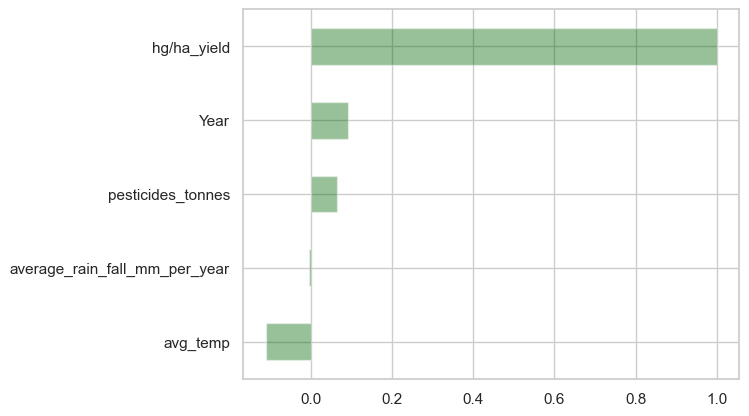

In [ ]:
corr = df.corr(numeric_only=True)
corr['hg/ha_yield'].sort_values(ascending=False)
corr['hg/ha_yield'].sort_values().plot(kind='barh',color='darkgreen', alpha=0.4)
plt.show()

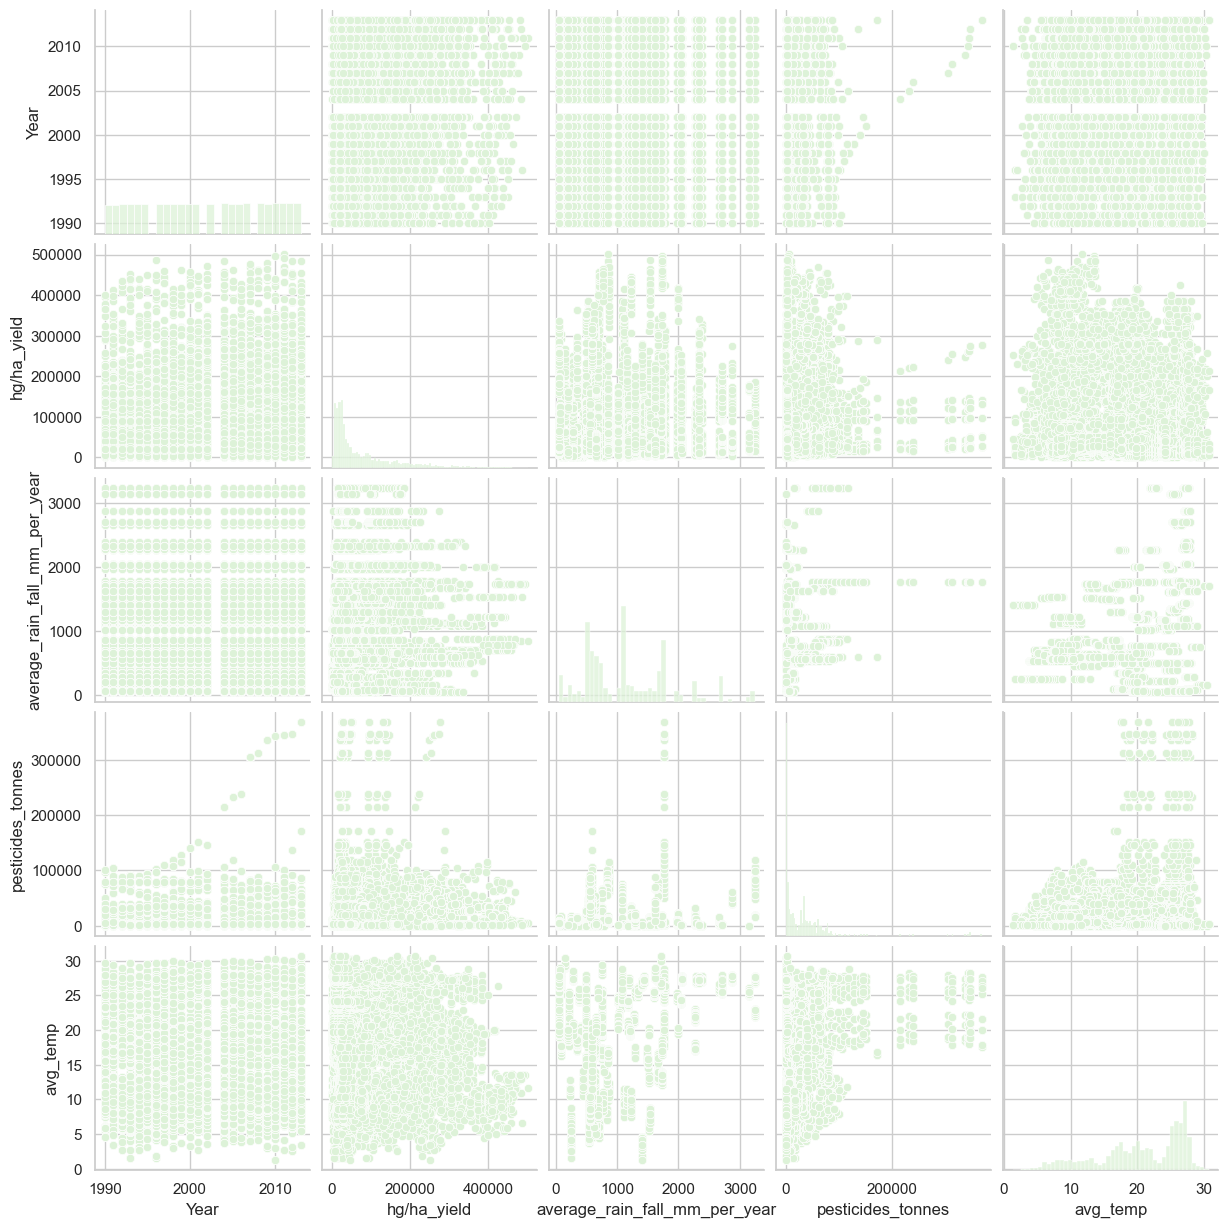

In [ ]:
cols =['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

sns.pairplot(df[cols])
plt.show()

In [ ]:
len(df.Area.unique())

101

In [ ]:
bycountry=df.groupby('Area')['hg/ha_yield'].sum().reset_index()
bycountry

,Area,hg/ha_yield
0,Albania,5711536
1,Algeria,6711464
2,Angola,5722563
3,Argentina,32864032
4,Armenia,4524100
...,...,...
96,Ukraine,5496901
97,United Kingdom,44335992
98,Uruguay,9539820
99,Zambia,7254311


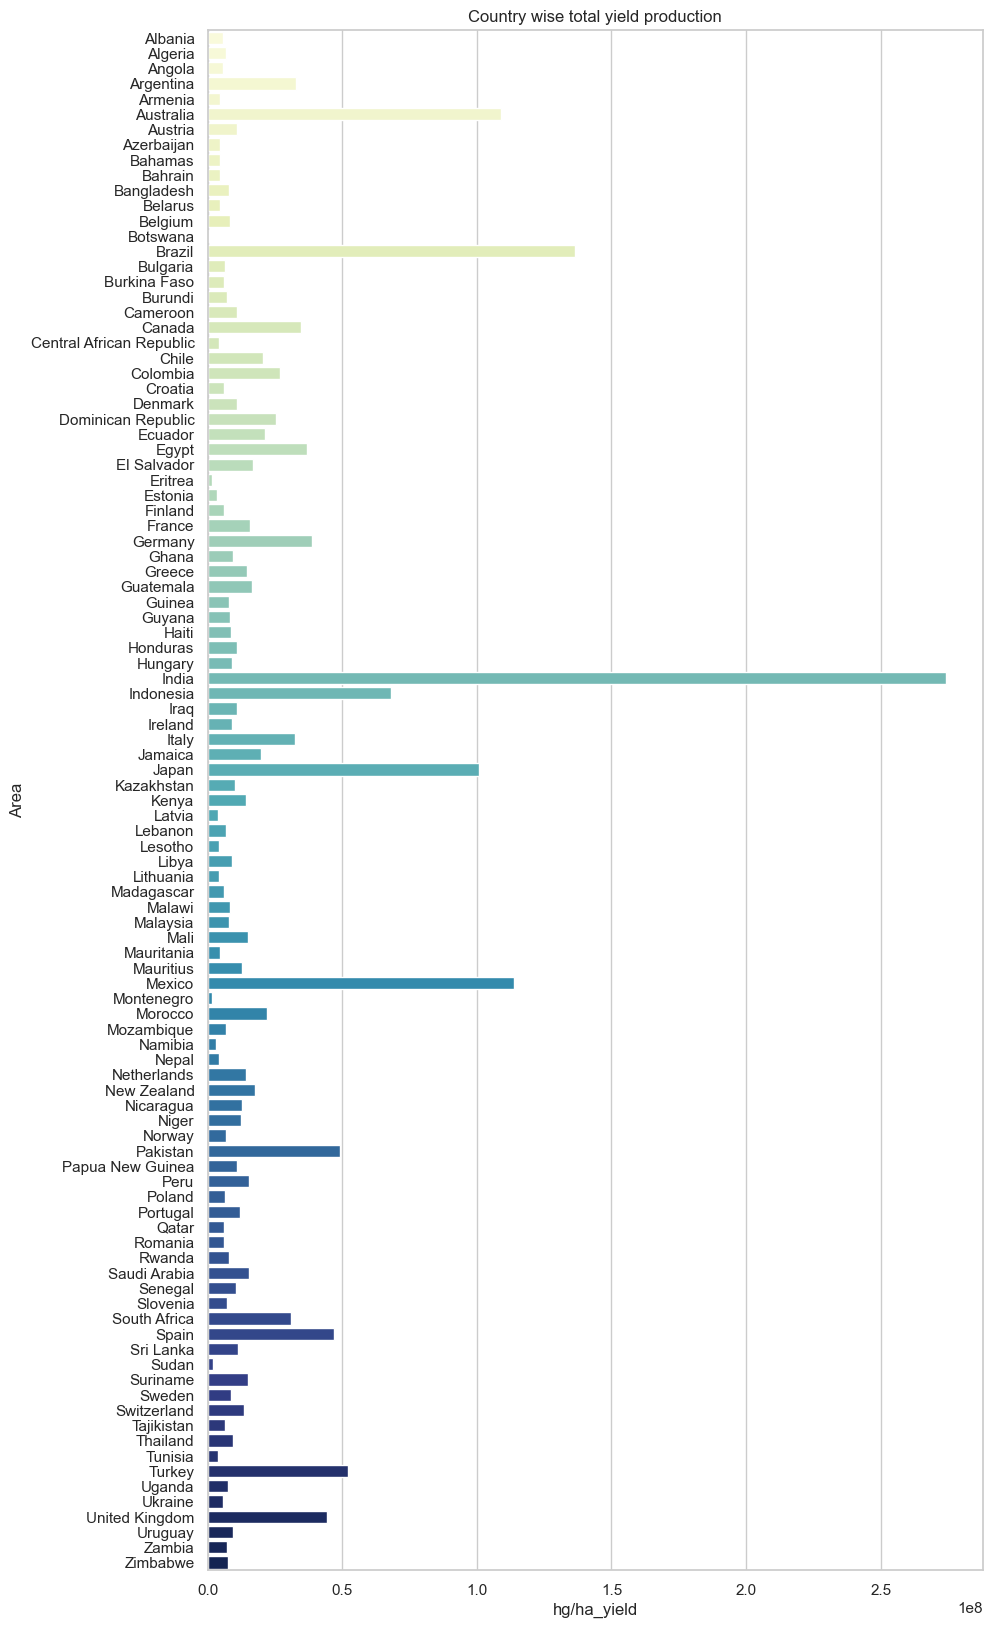

In [ ]:
plt.figure(figsize=(10,20))
sns.barplot(data=bycountry, x='hg/ha_yield', y='Area',palette='YlGnBu',hue='Area')
plt.title('Country wise total yield production')
plt.show()

In [ ]:
df['Year'].max()

np.int64(2013)

In [ ]:
byyear=df.groupby(['Area','Year'])['hg/ha_yield'].sum().reset_index()
byyear

,Area,Year,hg/ha_yield
0,Albania,1990,176310
1,Albania,1991,168855
2,Albania,1992,180438
3,Albania,1993,202391
4,Albania,1994,139924
...,...,...,...
2245,Zimbabwe,2009,308427
2246,Zimbabwe,2010,309348
2247,Zimbabwe,2011,304745
2248,Zimbabwe,2012,313366


In [ ]:
byyear[byyear['Year']==byyear['Year'].max()]

,Area,Year,hg/ha_yield
22,Albania,2013,380935
45,Algeria,2013,433745
68,Angola,2013,315282
91,Argentina,2013,1523978
112,Armenia,2013,313677
...,...,...,...
2157,Ukraine,2013,365596
2180,United Kingdom,2013,1931324
2203,Uruguay,2013,555620
2226,Zambia,2013,385279


In [ ]:
country2013=byyear[byyear['Year']==byyear['Year'].max()][['Area',"hg/ha_yield"]]
country2013

,Area,hg/ha_yield
22,Albania,380935
45,Algeria,433745
68,Angola,315282
91,Argentina,1523978
112,Armenia,313677
...,...,...
2157,Ukraine,365596
2180,United Kingdom,1931324
2203,Uruguay,555620
2226,Zambia,385279


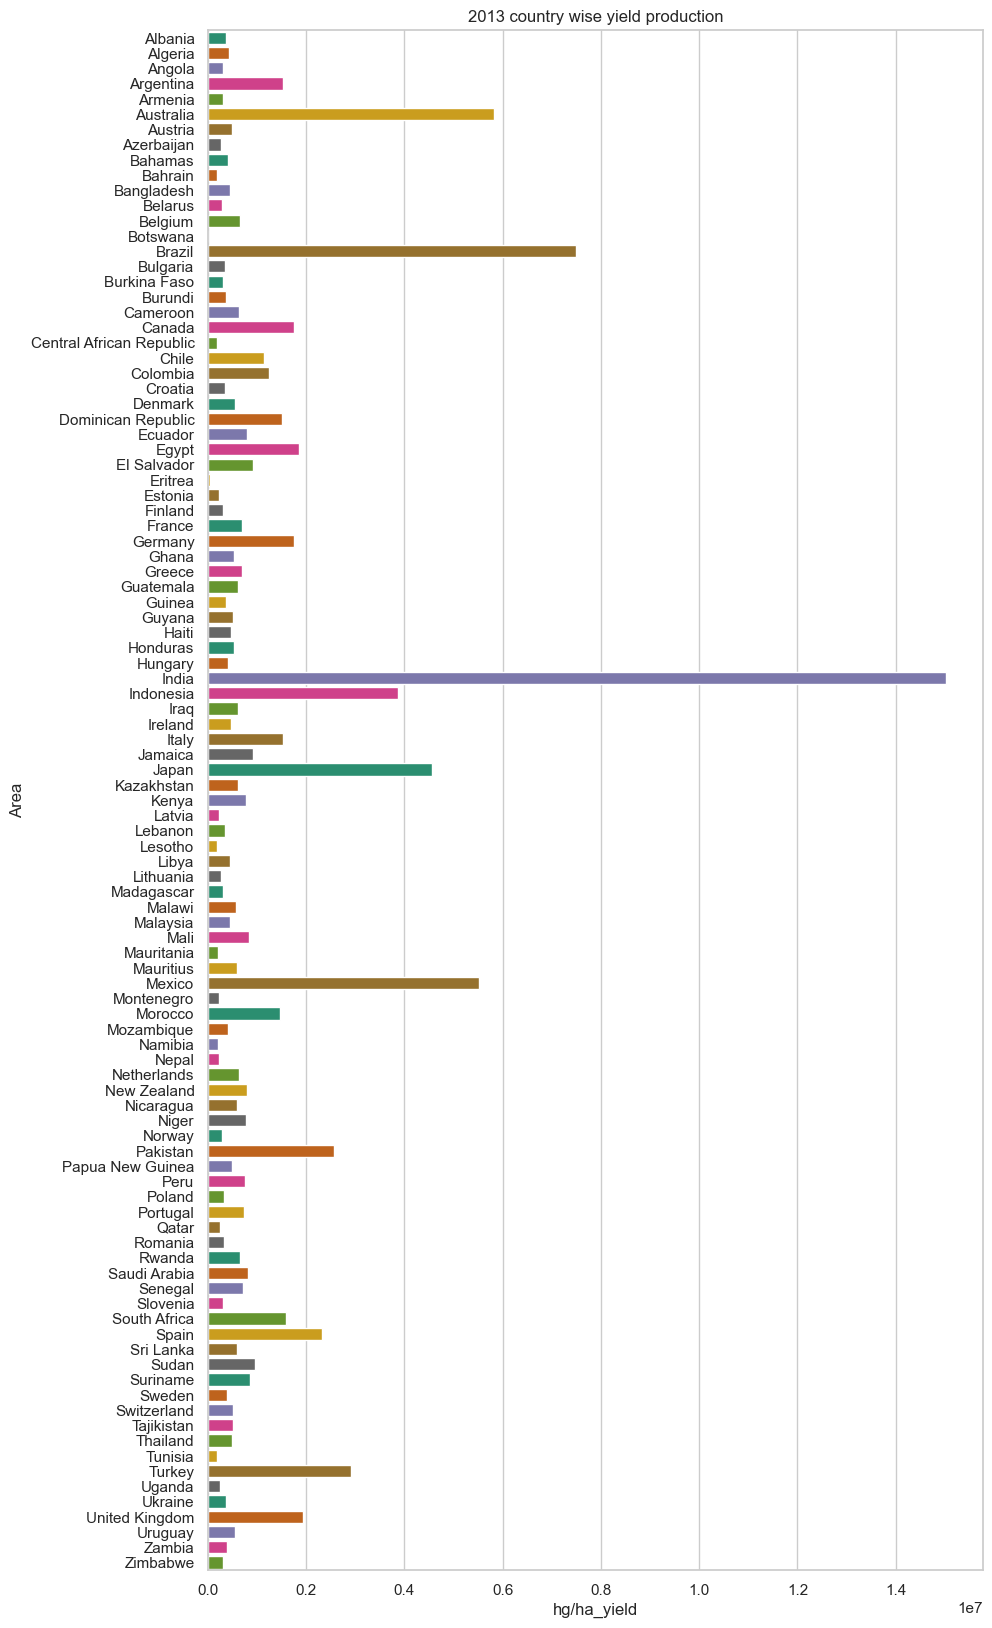

In [ ]:
plt.figure(figsize=(10,20))
sns.barplot(data=country2013, x='hg/ha_yield', y='Area',palette='Dark2',hue='Area')
plt.title('2013 country wise yield production')
plt.show()

In [ ]:
Items=df['Item'].value_counts().reset_index()
Items

,Item,count
0,Potatoes,3956
1,Maize,3824
2,Wheat,3539
3,"Rice, paddy",3091
4,Soybeans,2940
5,Sorghum,2770
6,Sweet potatoes,2593
7,Cassava,1889
8,Yams,774
9,Plantains and others,556


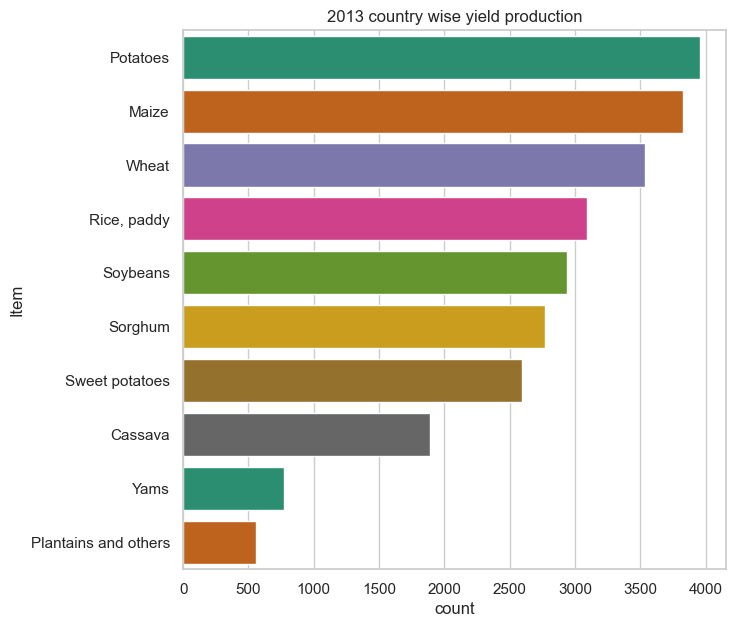

In [ ]:
plt.figure(figsize=(7,7))
sns.barplot(data=Items, x='count', y='Item', palette='Dark2',hue='Item')
plt.title('2013 country wise yield production')
plt.show()

In [ ]:
yield_by_item = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False).reset_index()

yield_by_item

,Item,hg/ha_yield
0,Potatoes,198665.725228
1,Cassava,145649.692430
2,Sweet potatoes,119656.515619
3,Yams,112105.633075
4,Plantains and others,106041.320144
5,"Rice, paddy",41296.028470
6,Maize,37139.320345
7,Wheat,30125.681266
8,Sorghum,19099.774729
9,Soybeans,16992.190136


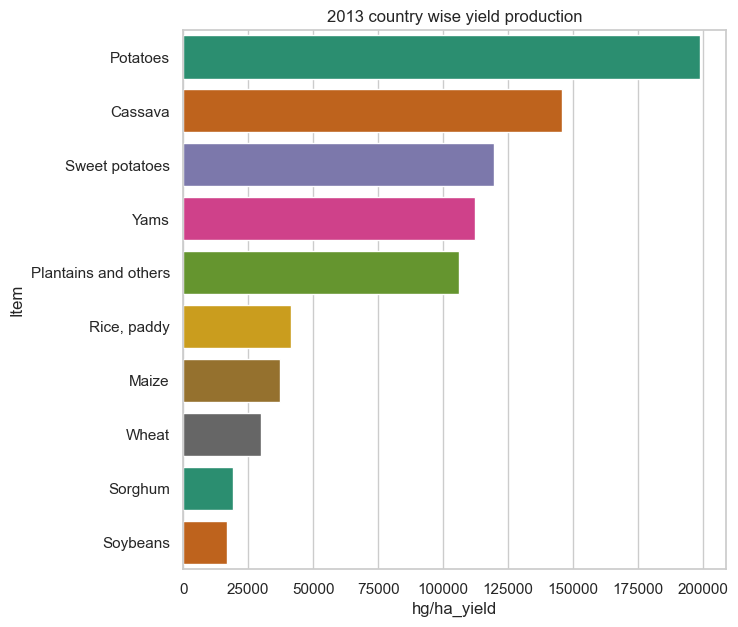

In [ ]:
plt.figure(figsize=(7,7))
sns.barplot(data=yield_by_item, x='hg/ha_yield', y='Item', palette='Dark2',hue='Item')
plt.title('2013 country wise yield production')
plt.show()